## Relationships validations

### Imports

In [ ]:
import pandas as pd
import great_expectations as gx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

### Loading Data

In [2]:
df = pd.read_csv('../../data/raw/diabetes_prediction_dataset.csv')
df = df[df['gender'] != 'Other']
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 99982 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               99982 non-null  str    
 1   age                  99982 non-null  float64
 2   hypertension         99982 non-null  int64  
 3   heart_disease        99982 non-null  int64  
 4   smoking_history      99982 non-null  str    
 5   bmi                  99982 non-null  float64
 6   HbA1c_level          99982 non-null  float64
 7   blood_glucose_level  99982 non-null  int64  
 8   diabetes             99982 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 7.6 MB


In [41]:
df['gender'].value_counts()

gender
Female    58552
Male      41430
Name: count, dtype: int64

In [42]:
df['hypertension'].value_counts()

hypertension
0    92497
1     7485
Name: count, dtype: int64

In [43]:
df['heart_disease'].value_counts()

heart_disease
0    96040
1     3942
Name: count, dtype: int64

In [44]:
df['smoking_history'].value_counts()

smoking_history
No Info        35810
never          35092
former          9352
current         9286
not current     6439
ever            4003
Name: count, dtype: int64

In [45]:
df['diabetes'].value_counts()

diabetes
0    91482
1     8500
Name: count, dtype: int64

In [47]:
gender_map = {
    'Female': 0, 
    'Male': 1
}
df['gender'] = df['gender'].map(gender_map)

In [51]:
df = df.drop('diabetes', axis=1)

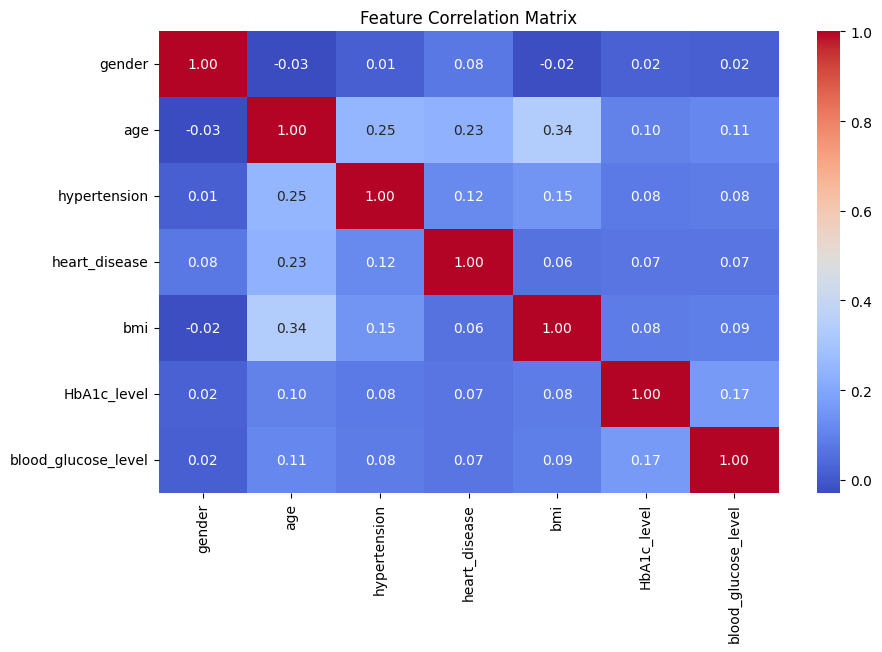

                       gender       age  hypertension  heart_disease  \
gender               1.000000 -0.030369      0.014381       0.077886   
age                 -0.030369  1.000000      0.251163       0.233352   
hypertension         0.014381  0.251163      1.000000       0.121253   
heart_disease        0.077886  0.233352      0.121253       1.000000   
bmi                 -0.023023  0.337378      0.147679       0.061203   
HbA1c_level          0.020044  0.101343      0.080941       0.067591   
blood_glucose_level  0.017196  0.110679      0.084436       0.070071   

                          bmi  HbA1c_level  blood_glucose_level  
gender              -0.023023     0.020044             0.017196  
age                  0.337378     0.101343             0.110679  
hypertension         0.147679     0.080941             0.084436  
heart_disease        0.061203     0.067591             0.070071  
bmi                  1.000000     0.083017             0.091310  
HbA1c_level          0.0830

In [54]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr(method='pearson')

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()
print(corr_matrix)

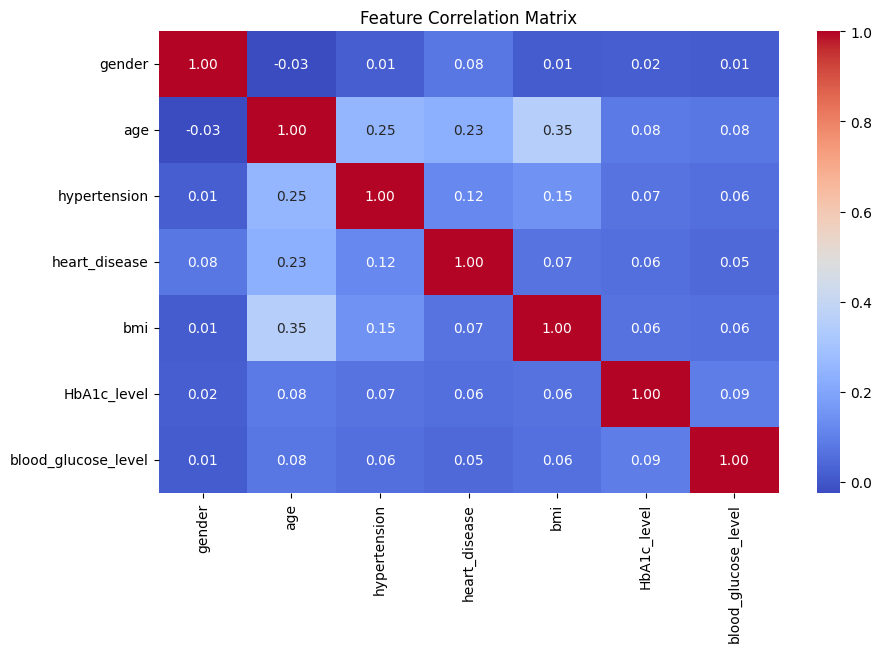

                       gender       age  hypertension  heart_disease  \
gender               1.000000 -0.025888      0.014381       0.077886   
age                 -0.025888  1.000000      0.254192       0.234429   
hypertension         0.014381  0.254192      1.000000       0.121253   
heart_disease        0.077886  0.234429      0.121253       1.000000   
bmi                  0.012084  0.351294      0.147461       0.069612   
HbA1c_level          0.017832  0.083620      0.066759       0.055193   
blood_glucose_level  0.011513  0.075426      0.056385       0.045144   

                          bmi  HbA1c_level  blood_glucose_level  
gender               0.012084     0.017832             0.011513  
age                  0.351294     0.083620             0.075426  
hypertension         0.147461     0.066759             0.056385  
heart_disease        0.069612     0.055193             0.045144  
bmi                  1.000000     0.063373             0.058318  
HbA1c_level          0.0633

: 

In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr(method='spearman')

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()
print(corr_matrix)